# Guía de Trabajo Práctico 3

**Materia**: Aprendizaje Profundo Basado en la Física (optativa del Instituto Balseiro)

**Docente**: José I. Robledo

**Edición**: abril-mayo 2026

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorobledo/apbf/blob/main/APBF/practicos/Guia_Semana_03_PINNs.ipynb)

---

## Problema 1: PINN en PyTorch para Poisson 1D


Resolver
$$
u''(x) = -\pi^2 \sin(\pi x), \quad x\in[0,1],\quad u(0)=u(1)=0
$$
cuya solución analítica es `u(x)=sin(pi x)`.

1. Crear una red pequeña `x -> u(x)`.
2. Muestrear puntos interiores y de borde.
3. Usar `autograd` para obtener `u_x` y `u_xx`.
4. Construir una loss con residual de PDE y condiciones de borde.
5. Entrenar y comparar contra la solución analítica.

In [12]:
import torch
from torch import nn
#Crear una red pequena
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_N, hidden_L):
        super(MLP, self).__init__()
        layers = []
        
        # Capa de entrada
        layers.append(nn.Linear(input_dim, hidden_N))
        layers.append(nn.Tanh())
        
        # Capas ocultas
        for _ in range(hidden_L - 1):
            layers.append(nn.Linear(hidden_N, hidden_N))
            layers.append(nn.Tanh())
            
        # Capa de salida
        layers.append(nn.Linear(hidden_N, 1))
        # layers.append(nn.Sigmoid())  # convierte salida a rango [0,1]
        
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

#Muestrear puntos interiores al intervalo
def sample_interior_points(num_points, low=0.0, high=1.0):
    return torch.rand(num_points, 1) * (high - low) + low

#3. Usar `autograd` para obtener `u_x` y `u_xx`.
def compute_gradients(u, x):
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    return u_x, u_xx

def calcular_pde_loss(model, x):
    x.requires_grad_(True)
    u = model(x)
    u_x, u_xx = compute_gradients(u, x)
    pde_residual = u_xx + torch.pi**2 * torch.sin(torch.pi * x)
    return torch.mean(pde_residual**2)

def calcular_boundary_loss(model):
    # Puntos en la frontera
    x_boundary = torch.tensor([[0.0], [1.0]], requires_grad=True)
    u_boundary = model(x_boundary)
    # Condición de frontera: u(0) = 0, u(1) = 0
    boundary_loss = torch.mean(u_boundary**2)
    return boundary_loss

In [23]:
def train(model, num_epochs=1000, pde_weight=1.0, boundary_weight=1.0):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    train_losses, test_losses = [], []

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()

        x_interior = sample_interior_points(63)
        pde_loss = calcular_pde_loss(model, x_interior)
        boundary_loss = calcular_boundary_loss(model)
        total_loss = pde_weight * pde_loss + boundary_weight * boundary_loss

        train_losses.append(total_loss.item())
        total_loss.backward()
        optimizer.step()

        # Test loss (requires autograd for second derivatives)
        model.eval()
        x_test = sample_interior_points(30)
        test_pde_loss = calcular_pde_loss(model, x_test)
        test_boundary_loss = calcular_boundary_loss(model)
        test_total_loss = pde_weight * test_pde_loss + boundary_weight * test_boundary_loss
        test_losses.append(test_total_loss.item())

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, PDE Loss: {pde_loss.item()}, Boundary Loss: {boundary_loss.item()}")

    return train_losses, test_losses

model = MLP(input_dim=1, hidden_N=64, hidden_L=3)
train_losses, test_losses = train(model, num_epochs=4000)

Epoch 0, PDE Loss: 42.17946243286133, Boundary Loss: 0.005362429656088352
Epoch 100, PDE Loss: 0.1250625103712082, Boundary Loss: 0.5042861700057983
Epoch 200, PDE Loss: 0.0008314051665365696, Boundary Loss: 1.37832239488489e-05
Epoch 300, PDE Loss: 0.0006684364634566009, Boundary Loss: 5.470904511639674e-07
Epoch 400, PDE Loss: 0.0006161088240332901, Boundary Loss: 4.0660011109139305e-06
Epoch 500, PDE Loss: 0.001412607147358358, Boundary Loss: 0.00010015949374064803
Epoch 600, PDE Loss: 0.0009146754746325314, Boundary Loss: 1.848352258093655e-05
Epoch 700, PDE Loss: 0.0006416454561986029, Boundary Loss: 3.0032044833205873e-06
Epoch 800, PDE Loss: 0.00040359972626902163, Boundary Loss: 5.333974968380062e-06
Epoch 900, PDE Loss: 0.0007129539735615253, Boundary Loss: 4.359673766884953e-06
Epoch 1000, PDE Loss: 0.00048613702529110014, Boundary Loss: 1.0798325092764571e-05
Epoch 1100, PDE Loss: 0.0004886895185336471, Boundary Loss: 2.308652710780734e-06
Epoch 1200, PDE Loss: 0.00040325894

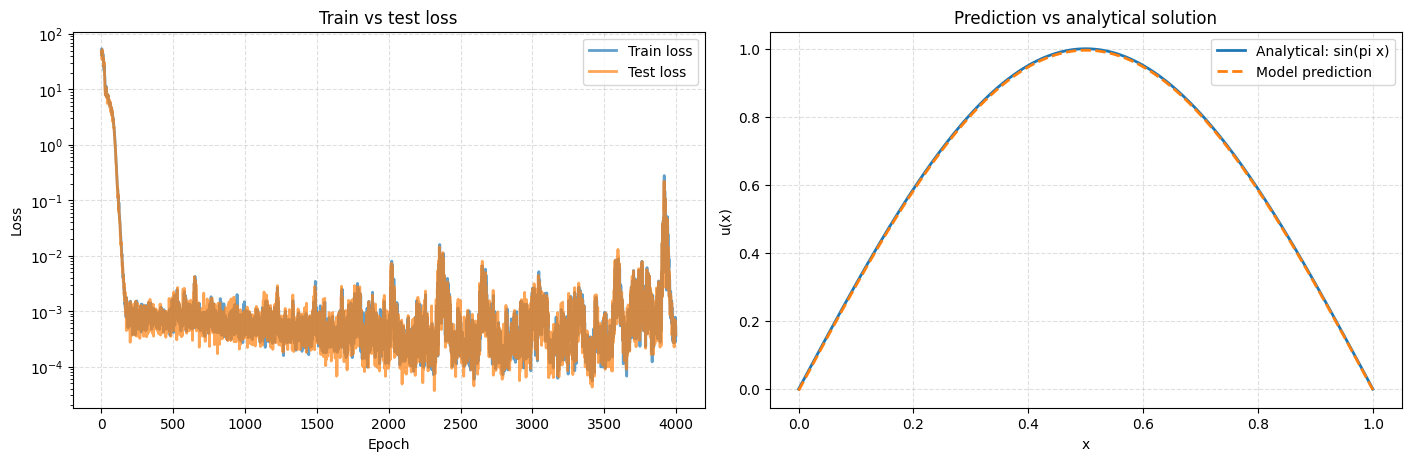

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Build prediction and analytical reference on a dense grid
x_plot = torch.linspace(0.0, 1.0, 300).reshape(-1, 1)
model.eval()
with torch.no_grad():
    u_pred = model(x_plot).cpu().numpy().squeeze()

x_np = x_plot.cpu().numpy().squeeze()
u_true = np.sin(np.pi * x_np)

# Single figure with both requested comparisons
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)

# 1) Train loss vs test loss
axes[0].plot(train_losses, label="Train loss", linewidth=2, alpha=0.7)
axes[0].plot(test_losses, label="Test loss", linewidth=2, alpha=0.7)
axes[0].set_yscale("log")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Train vs test loss")
axes[0].grid(True, linestyle="--", alpha=0.4)
axes[0].legend()

# 2) Model prediction vs analytical solution u(x)=sin(pi x)
axes[1].plot(x_np, u_true, label="Analytical: sin(pi x)", linewidth=2)
axes[1].plot(x_np, u_pred, "--", label="Model prediction", linewidth=2)
axes[1].set_xlabel("x")
axes[1].set_ylabel("u(x)")
axes[1].set_title("Prediction vs analytical solution")
axes[1].grid(True, linestyle="--", alpha=0.4)
axes[1].legend()

plt.show()

---

## Problema 2: Poisson 2D con DeepXDE


Resolver con `deepxde` un problema de Poisson 2D sobre el cuadrado unitario .

$$
\Delta u(x,y) = 2\pi^2 \sin(\pi x)\sin(\pi y), \quad (x,y)\in[0,1]^2
$$
con condición de borde homogénea y solución analítica
$$
u(x,y) = -\sin(\pi x)\sin(\pi y).
$$

1. Definir la geometría del cuadrado unitario.
2. Declarar la PDE y la condición de borde de Dirichlet homogénea.
3. Armar el objeto `dde.data.PDE`.
4. Entrenar una red `FNN` que estime la solución en el dominio.
5. Evaluar la solución sobre una grilla y compararla con la expresión analítica.

In [ ]:
import torch
import deepxde as dde
from torch import nn

#Definir geometria del cuadrado unitario
geom = dde.geometry.Rectangle([0, 0], [1, 1])

#Definir la PDE \Delta u(x,y) = 2\pi^2 \sin(\pi x)\sin(\pi y), \quad (x,y)\in[0,1]^2
def pde(x, u):
    u_xx = dde.grad.hessian(u, x, i=0, j=0)
    u_yy = dde.grad.hessian(u, x, i=1, j=1)
    return u_xx + u_yy - 2 * torch.pi**2 * torch.sin(torch.pi * x[:, 0:1]) * torch.sin(torch.pi * x[:, 1:2])

def boundary(x, on_boundary):
    return on_boundary

def boundary_value(x):
    # u = 0 en todo el borde del cuadrado
    return 0.0



bc = dde.icbc.DirichletBC(geom, boundary_value, boundary)

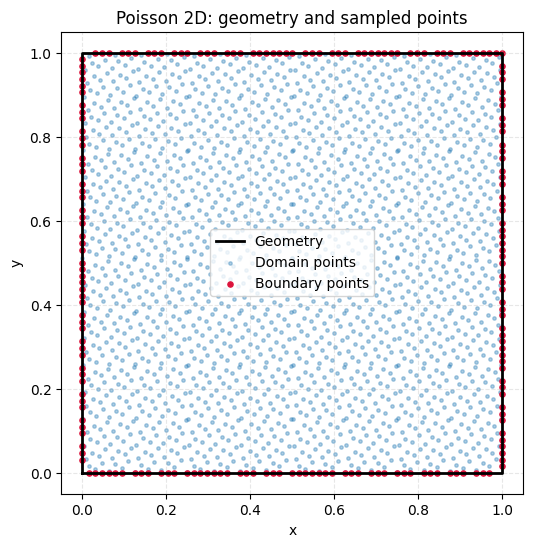

In [32]:
#Build data.PDE
data = dde.data.PDE(geom, pde, bc, num_domain=2000, num_boundary=200)

#Plot the geometry and the sampled points
# Generate/access sampled points from the PDE dataset
data.train_next_batch()
x_domain = data.train_x_all
x_boundary = data.train_x_bc

fig2, ax = plt.subplots(figsize=(6, 6))

# Geometry (unit square)
ax.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], "k-", lw=2, label="Geometry")

# Sampled points
ax.scatter(x_domain[:, 0], x_domain[:, 1], s=6, alpha=0.35, label="Domain points")
ax.scatter(x_boundary[:, 0], x_boundary[:, 1], s=14, c="crimson", label="Boundary points")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Poisson 2D: geometry and sampled points")
ax.set_aspect("equal")
ax.grid(True, ls="--", alpha=0.3)
ax.legend()
plt.show()

In [33]:
#FNN
net = dde.nn.FNN([2] + [50] * 4 + [1], "tanh", "Glorot normal")
model = dde.Model(data, net)
model.compile("adam", lr=0.001)

train_loss_history = model.train(epochs=4000, display_every=100)


Compiling model...
'compile' took 0.022690 s

Training model...

Step      Train loss              Test loss               Test metric
0         [8.87e+01, 3.62e-02]    [8.87e+01, 3.62e-02]    []  
100       [6.00e+00, 1.33e+00]    [6.00e+00, 1.33e+00]    []  
200       [3.55e-01, 9.34e-02]    [3.55e-01, 9.34e-02]    []  
300       [6.36e-02, 2.97e-02]    [6.36e-02, 2.97e-02]    []  
400       [3.50e-02, 1.50e-02]    [3.50e-02, 1.50e-02]    []  
500       [2.35e-02, 1.27e-02]    [2.35e-02, 1.27e-02]    []  
600       [1.69e-02, 1.21e-02]    [1.69e-02, 1.21e-02]    []  
700       [1.26e-02, 1.15e-02]    [1.26e-02, 1.15e-02]    []  
800       [9.38e-03, 1.08e-02]    [9.38e-03, 1.08e-02]    []  
900       [7.44e-03, 1.01e-02]    [7.44e-03, 1.01e-02]    []  
1000      [2.19e-02, 9.55e-03]    [2.19e-02, 9.55e-03]    []  
1100      [4.28e-03, 8.83e-03]    [4.28e-03, 8.83e-03]    []  
1200      [3.80e-03, 8.46e-03]    [3.80e-03, 8.46e-03]    []  
1300      [3.35e-03, 8.17e-03]    [3.35e-03, 8

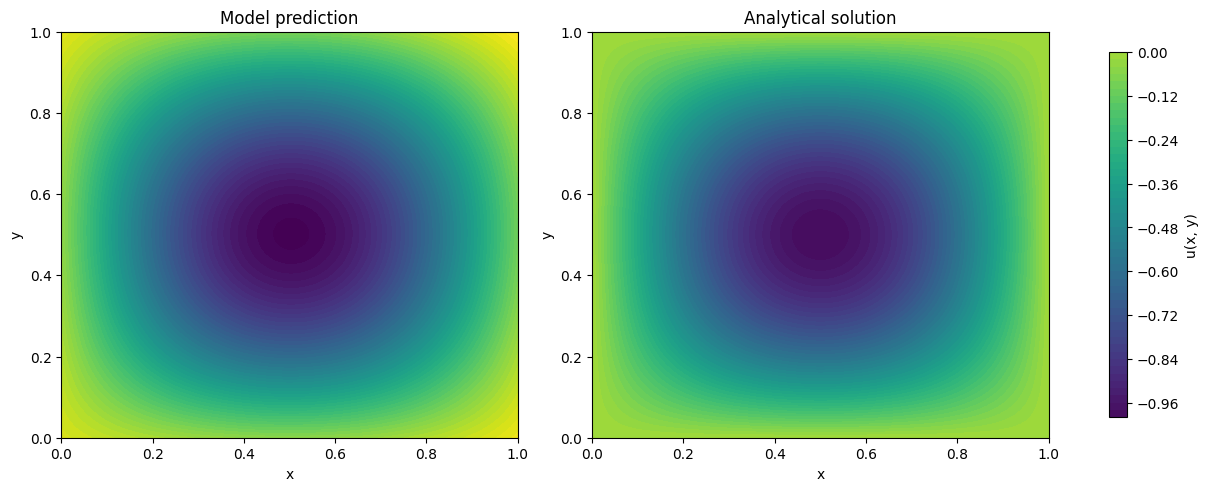

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Evaluate prediction and analytical solution on a regular 2D grid
n = 120
xv = np.linspace(0.0, 1.0, n)
yv = np.linspace(0.0, 1.0, n)
X, Y = np.meshgrid(xv, yv)
XY = np.hstack([X.reshape(-1, 1), Y.reshape(-1, 1)])

u_pred = model.predict(XY).reshape(n, n)
u_true = -np.sin(np.pi * X) * np.sin(np.pi * Y)

# Use shared color limits for fair visual comparison
vmin = min(u_pred.min(), u_true.min())
vmax = max(u_pred.max(), u_true.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

im0 = axes[0].contourf(X, Y, u_pred, levels=60, cmap="viridis", vmin=vmin, vmax=vmax)
axes[0].set_title("Model prediction")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

im1 = axes[1].contourf(X, Y, u_true, levels=60, cmap="viridis", vmin=vmin, vmax=vmax)
axes[1].set_title("Analytical solution")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

fig.colorbar(im1, ax=axes, shrink=0.9, label="u(x, y)")
plt.show()

---

## Problema 2.b: Helmholtz 2D con métrica de prueba y ajuste de hiperparámetros (OPCIONAL)

Retomar el problema anterior de Poisson 2D, cuya solución analítica era

$$
u(x,y) = -\sin(\pi x)\sin(\pi y).
$$

Observar que, para esta solución particular, se cumple que

$$
\Delta u(x,y) = -2\pi^2 u(x,y),
$$

de modo que el mismo campo puede reinterpretarse como solución de una ecuación de Helmholtz homogénea:

$$
-\Delta u(x,y) - k_0^2 u(x,y) = 0, \qquad (x,y)\in[0,1]^2,
$$

con condición de borde de Dirichlet homogénea

$$
u(x,y)=0, \qquad (x,y)\in\partial\Omega,
$$

y con

$$
k_0^2 = 2\pi^2.
$$

Resolver este problema con `DeepXDE`, usando como solución de referencia

$$
u(x,y) = -\sin(\pi x)\sin(\pi y).
$$

1. Definir la geometría rectangular y escribir el residual de la ecuación de Helmholtz usando derivadas automáticas de segundo orden.
2. Declarar la condición de borde de Dirichlet homogénea, o bien imponerla mediante una transformación de salida si se desea trabajar con restricciones duras.
3. Construir el objeto `dde.data.PDE` incluyendo la solución exacta para poder evaluar una métrica de prueba razonable durante el entrenamiento.
4. Entrenar una red `FNN` utilizando, por ejemplo, la métrica `"l2 relative error"` para monitorear la calidad de la solución sobre el conjunto de test.
5. Comparar la solución predicha con la solución analítica sobre una grilla bidimensional y reportar el error final.
6. Realizar una optimización de hiperparámetros inspirada en el [demo oficial de `DeepXDE`](https://deepxde.readthedocs.io/en/v1.15.0/demos/pinn_forward/helmholtz.2d.dirichlet.hpo.html) para Helmholtz 2D, explorando al menos tasa de aprendizaje, cantidad de capas, número de neuronas por capa y función de activación.
7. Definir una función objetivo razonable para la optimización, por ejemplo el mínimo error de test o la mejor métrica `l2 relative error` obtenida durante el entrenamiento.
8. Presentar la mejor configuración encontrada y compararla con una configuración base.

In [2]:
import torch
import deepxde as dde
from torch import nn

# Definir geometria del cuadrado unitario
geom = dde.geometry.Rectangle([0, 0], [1, 1])

# Helmholtz 2D: -Δu - k0^2 u = 0  <=>  Δu + k0^2 u = 0, con k0^2 = 2*pi^2
def pde(x, u):
    u_xx = dde.grad.hessian(u, x, i=0, j=0)
    u_yy = dde.grad.hessian(u, x, i=1, j=1)
    return u_xx + u_yy + 2 * torch.pi**2 * u

def boundary(x, on_boundary):
    return on_boundary

def boundary_value(x):
    # u = 0 en todo el borde del cuadrado
    return 0.0

bc = dde.icbc.DirichletBC(geom, boundary_value, boundary)

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [ ]:
import numpy as np
# Puntos observados de la solución exacta (anclas supervisadas)
rng = np.random.default_rng(1234)
n_exact_points = 300
x_exact = rng.uniform(0.0, 1.0, size=(n_exact_points, 2))
y_exact = -np.sin(np.pi * x_exact[:, 0:1]) * np.sin(np.pi * x_exact[:, 1:2])
exact_bc = dde.icbc.PointSetBC(x_exact, y_exact, component=0)

data = dde.data.PDE(
    geom,
    pde,
    [bc, exact_bc],
    num_domain=2025,
    num_boundary=200,
    num_test=2025,
    solution=lambda x: -np.sin(np.pi * x[:, 0:1]) * np.sin(np.pi * x[:, 1:2]),
)

# Red para 2.b (Helmholtz)
net = dde.nn.FNN([2] + [50] * 5 + [1], "swish", "Glorot normal")
model = dde.Model(data, net)
model.compile("adam", lr=0.001, metrics=["l2 relative error"], loss_weights=[1.0, 1.0, 10.0])
train_loss_history = model.train(epochs=4000, display_every=100)

Compiling model...
'compile' took 0.000800 s

Training model...

Step      Train loss                        Test loss                         Test metric   
0         [1.16e-04, 2.74e-07, 2.47e+00]    [9.21e-05, 2.74e-07, 2.47e+00]    [1.00e+00]    
100       [2.56e-01, 7.75e-04, 1.94e+00]    [2.65e-01, 7.75e-04, 1.94e+00]    [8.88e-01]    
200       [2.44e-01, 6.21e-04, 1.94e+00]    [2.38e-01, 6.21e-04, 1.94e+00]    [8.87e-01]    
300       [2.49e-01, 6.32e-04, 1.93e+00]    [2.43e-01, 6.32e-04, 1.93e+00]    [8.84e-01]    
400       [2.58e-01, 6.63e-04, 1.90e+00]    [2.52e-01, 6.63e-04, 1.90e+00]    [8.79e-01]    
500       [2.15e-01, 1.03e-03, 1.60e+00]    [2.25e-01, 1.03e-03, 1.60e+00]    [8.06e-01]    
600       [3.35e-01, 1.66e-02, 4.01e-01]    [3.33e-01, 1.66e-02, 4.01e-01]    [4.02e-01]    
700       [4.92e-02, 2.01e-02, 7.48e-02]    [4.97e-02, 2.01e-02, 7.48e-02]    [1.77e-01]    
800       [2.86e-02, 1.94e-02, 6.71e-02]    [2.93e-02, 1.94e-02, 6.71e-02]    [1.68e-01]    
900  

: 

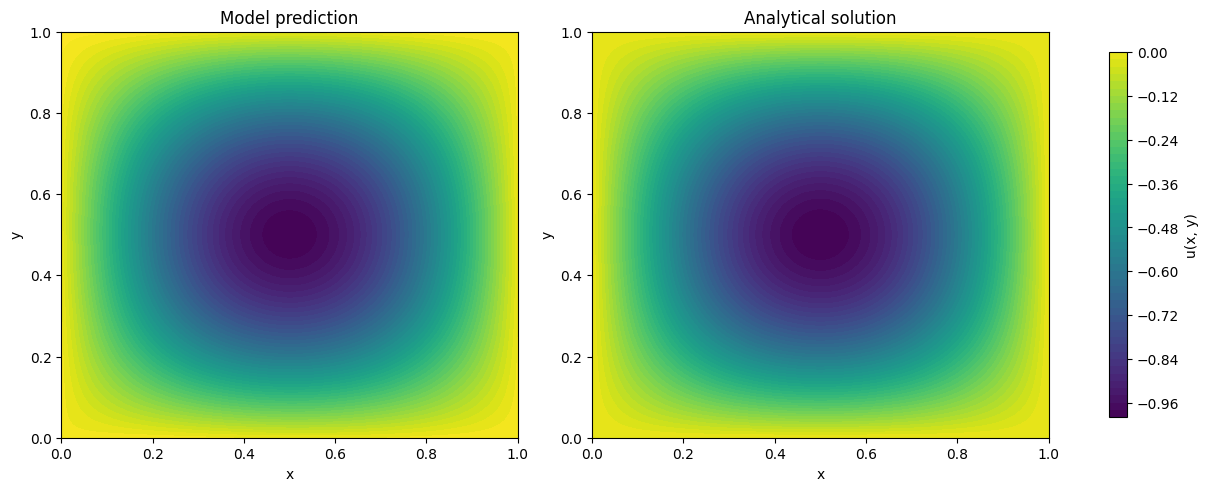

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Evaluate prediction and analytical solution on a regular 2D grid
n = 120
xv = np.linspace(0.0, 1.0, n)
yv = np.linspace(0.0, 1.0, n)
X, Y = np.meshgrid(xv, yv)
XY = np.hstack([X.reshape(-1, 1), Y.reshape(-1, 1)])

u_pred = model.predict(XY).reshape(n, n)
u_true = -np.sin(np.pi * X) * np.sin(np.pi * Y)

# Use shared color limits for fair visual comparison
vmin = min(u_pred.min(), u_true.min())
vmax = max(u_pred.max(), u_true.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

im0 = axes[0].contourf(X, Y, u_pred, levels=60, cmap="viridis", vmin=vmin, vmax=vmax)
axes[0].set_title("Model prediction")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

im1 = axes[1].contourf(X, Y, u_true, levels=60, cmap="viridis", vmin=vmin, vmax=vmax)
axes[1].set_title("Analytical solution")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

fig.colorbar(im1, ax=axes, shrink=0.9, label="u(x, y)")
plt.show()

In [3]:
import numpy as np
import pandas as pd
import deepxde as dde
from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args

# -----------------------------
# Bayesian optimization for Helmholtz 2D
# Explores: learning rate, layers, neurons, activation
# -----------------------------
np.random.seed(43)

# Solution exacta para evaluar métrica L2 relativa
def exact_solution(x):
    return -np.sin(np.pi * x[:, 0:1]) * np.sin(np.pi * x[:, 1:2])

# Puntos ancla interiores para romper la solución trivial u=0
rng_anchor = np.random.default_rng(2026)
n_anchor = 300
x_anchor = rng_anchor.uniform(0.0, 1.0, size=(n_anchor, 2))
y_anchor = exact_solution(x_anchor)
anchor_bc = dde.icbc.PointSetBC(x_anchor, y_anchor, component=0)

# Space of the Bayesian search
space = [
    Real(1e-4, 1e-2, prior="log-uniform", name="lr"),
    Integer(2, 7, name="num_layers"),
    Integer(16, 80, name="num_neurons"),
    Categorical(["tanh", "sin", "swish"], name="activation"),
]

@use_named_args(space)
def objective(lr, num_layers, num_neurons, activation):
    data_trial = dde.data.PDE(
        geom,
        pde,
        [bc, anchor_bc],
        num_domain=2025,
        num_boundary=200,
        num_test=2025,
        solution=exact_solution,
    )

    net_trial = dde.nn.FNN([2] + [num_neurons] * num_layers + [1], activation, "Glorot normal")
    model_trial = dde.Model(data_trial, net_trial)
    model_trial.compile(
        "adam",
        lr=lr,
        metrics=["l2 relative error"],
        loss_weights=[1.0, 1.0, 10.0],
    )

    losshistory, train_state = model_trial.train(epochs=800, display_every=100)

    # Prefer the best test metric seen during training
    best_l2_rel = np.inf
    if hasattr(losshistory, "metrics_test") and len(losshistory.metrics_test) > 0:
        for metric_values in losshistory.metrics_test:
            if len(metric_values) > 0 and np.isfinite(metric_values[0]):
                best_l2_rel = min(best_l2_rel, float(metric_values[0]))

    # Fallback if the metric history is unavailable
    if not np.isfinite(best_l2_rel):
        xy_eval = np.random.rand(4000, 2)
        u_hat = model_trial.predict(xy_eval)
        u_ref = exact_solution(xy_eval)
        best_l2_rel = float(np.linalg.norm(u_hat - u_ref) / (np.linalg.norm(u_ref) + 1e-12))

    return best_l2_rel

# A modest Bayesian search budget keeps the notebook usable
bo_result = gp_minimize(
    objective,
    space,
    n_calls=12,
    n_initial_points=4,
    random_state=123,
    acq_func="EI",
)

best_params = {
    "lr": bo_result.x[0],
    "num_layers": bo_result.x[1],
    "num_neurons": bo_result.x[2],
    "activation": bo_result.x[3],
    "best_l2_rel": bo_result.fun,
}

print("\nMejor configuración encontrada:")
print(best_params)

# Retrain the best configuration so the active model matches the selected hyperparameters
best_data = dde.data.PDE(
    geom,
    pde,
    [bc, anchor_bc],
    num_domain=2025,
    num_boundary=200,
    num_test=2025,
    solution=exact_solution,
)

best_net = dde.nn.FNN(
    [2] + [best_params["num_neurons"]] * best_params["num_layers"] + [1],
    best_params["activation"],
    "Glorot normal",
)
best_model = dde.Model(best_data, best_net)
best_model.compile(
    "adam",
    lr=best_params["lr"],
    metrics=["l2 relative error"],
    loss_weights=[1.0, 1.0, 10.0],
)
train_loss_history = best_model.train(epochs=2000, display_every=200)

model = best_model
hpo_results = pd.DataFrame([best_params])

Compiling model...
'compile' took 2.688072 s

Training model...

Step      Train loss                        Test loss                         Test metric   
0         [8.78e-02, 3.21e-04, 2.58e+00]    [8.35e-02, 3.21e-04, 2.58e+00]    [9.81e-01]    
200       [2.89e-01, 7.52e-04, 2.07e+00]    [2.86e-01, 7.52e-04, 2.07e+00]    [8.78e-01]    
400       [5.00e-01, 5.44e-02, 8.05e-01]    [4.88e-01, 5.44e-02, 8.05e-01]    [5.55e-01]    
600       [5.84e-01, 4.99e-02, 3.27e-01]    [6.60e-01, 4.99e-02, 3.27e-01]    [3.65e-01]    
800       [1.11e-01, 1.92e-02, 2.56e-01]    [1.07e-01, 1.92e-02, 2.56e-01]    [3.15e-01]    

Best model at step 800:
  train loss: 3.86e-01
  test loss: 3.83e-01
  test metric: [3.15e-01]

'train' took 58.640837 s

Compiling model...
'compile' took 0.000620 s

Training model...

Step      Train loss                        Test loss                         Test metric   
0         [2.57e+01, 7.60e-02, 1.25e+00]    [2.54e+01, 7.60e-02, 1.25e+00]    [6.94e-01]    
200

In [5]:
hpo_results

,lr,num_layers,num_neurons,activation,best_l2_rel
0,0.009672,4,66,swish,0.151488


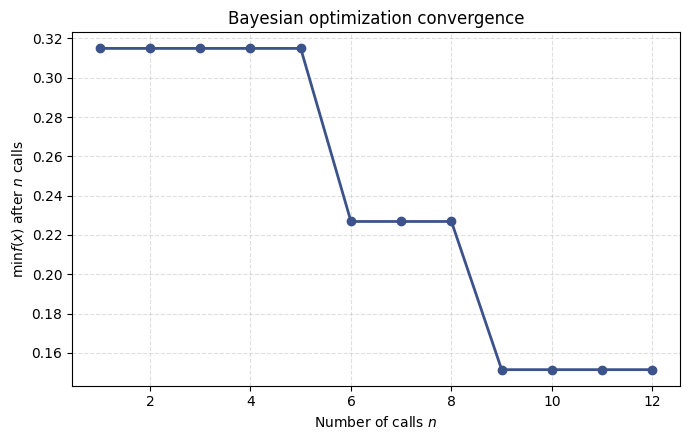

<Figure size 1100x1100 with 0 Axes>

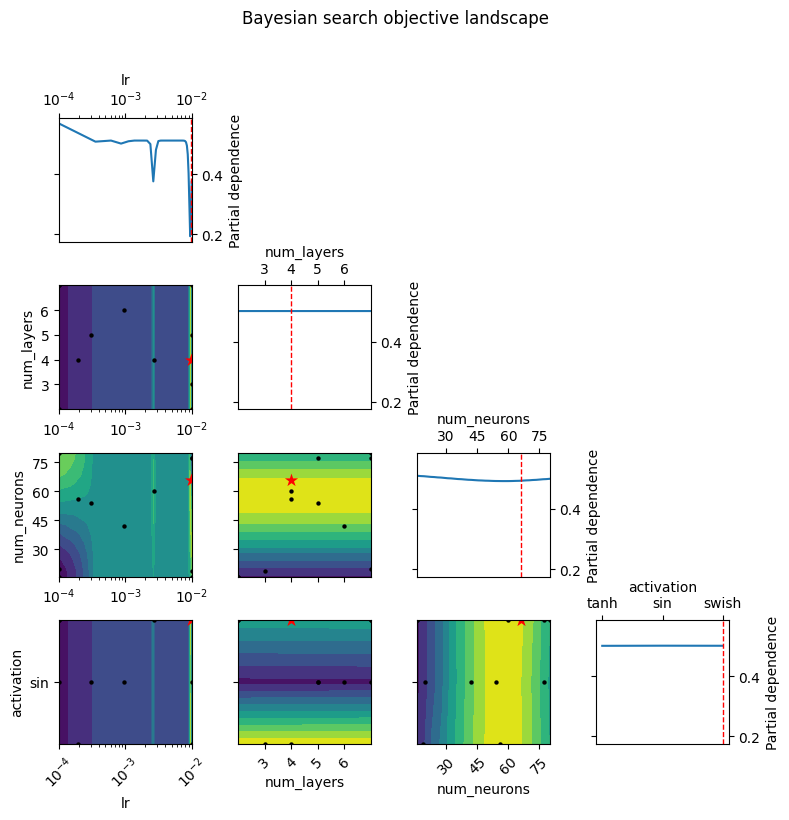

In [7]:
import matplotlib.pyplot as plt
from skopt.plots import plot_convergence, plot_objective

# 1) Convergence plot: best objective value vs iteration
fig1 = plt.figure(figsize=(7, 4.5))
plot_convergence(bo_result)
plt.title("Bayesian optimization convergence")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# 2) Pairwise objective landscape for hyperparameters
fig2 = plt.figure(figsize=(11, 11))
plot_objective(
    bo_result,
    dimensions=["lr", "num_layers", "num_neurons", "activation"],
)
plt.suptitle("Bayesian search objective landscape", y=1.02)
plt.tight_layout()
plt.show()

---

## Problema 3: Estimar la difusividad térmica: problema inverso


Se considera la ecuación de difusión unidimensional:
$$
u_t = \alpha u_{xx}
$$

donde $u(x,t)$ representa la temperatura y $\alpha > 0$ es la difusividad térmica desconocida. Supongamos que queremos estimar la solución con una PINN, en el dominio $x \in [0,1]$ y $t \in[0,1]$, con condiciones iniciales $  u(x,0) = \sin(\pi x)$, $u(0,t) = 0$ y $u(1,t) = 0$.

Cargar los datos observados de `data/difusion_1D.csv`. Contiene valores de $(x, t, u(x,t)$ para varios pares $(x,t)$ en el dominio mencionado.  

1. Utilizando `dde.icbc.DirichletBC` para las condiciones de contorno, `dde.icbc.IC` para las condiciones iniciales, y `dde.icbc.PointSetBC` para los puntos de colocacion provistos,  entrenar una PINN dependiente del tiempo con `dde.data.TimePDE` que estime el valor del parámetro $\alpha$. TIP: estas clases están pensadas para trabajar con numpy arrays.

2. Entrenar el modelo durante 5000 épocas con el optimizador Adam, y luego utilizar L-BFGS para el refinamiento de la solución.  

In [43]:
import pandas as pd
import deepxde as dde
import numpy as np

# Cargar data de data/difusion_1D.csv
data = pd.read_csv("data/difusion_1D.csv")

In [5]:
data.head()

,x,t,u
0,0.330882,0.233780,0.342579
1,0.896639,0.682918,0.021526
2,0.049308,0.864501,0.005083
3,0.829517,0.009418,0.491721
4,0.264606,0.743118,0.039303


In [44]:
#Condiciones de Dirichlet
def boundary(x, on_boundary):
    return on_boundary

def boundary_value(x):
    return 0.0

def u0(x):
    return np.sin(np.pi * x[:, 0:1])

#Definimos PDE
def pde(x, u, alpha):
    u_t = dde.grad.jacobian(u, x, i=0, j=1)
    u_xx = dde.grad.hessian(u, x, i=0, j=0)
    return u_t - alpha * u_xx

geom = dde.geometry.Interval(0.0, 1.0)
time_domain = dde.geometry.TimeDomain(0.0, 1.0)
geomtime = dde.geometry.GeometryXTime(geom, time_domain)

# Rebuild BC/IC on the space-time geometry (required by TimePDE)
bc = dde.icbc.DirichletBC(geomtime, boundary_value, boundary)
ci = dde.icbc.IC(geomtime, u0, lambda _, on_initial: on_initial)
pointset_bc = dde.icbc.PointSetBC(
    data[["x", "t"]].values,
    data["u"].values.reshape(-1, 1),
    component=0,
)

# If alpha is not yet defined as trainable parameter
alpha = dde.Variable(0.1)

data = dde.data.TimePDE(
    geomtime,
    lambda x, u: pde(x, u, alpha),
    [bc, ci, pointset_bc],
    num_domain=2000,
    num_boundary=2000,
    num_initial=200,
)

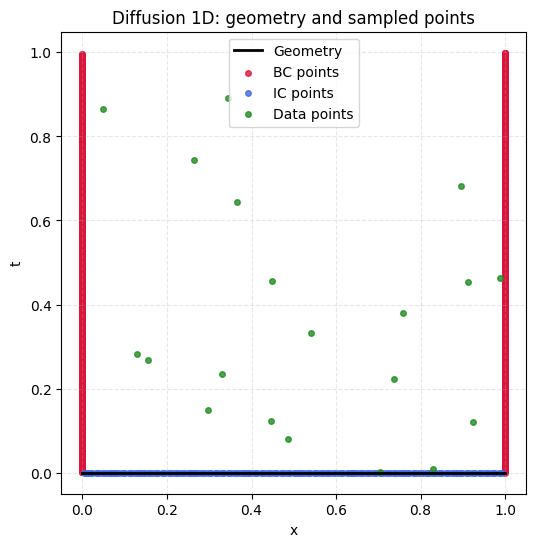

In [45]:
#Plot the points
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 6))
# Geometry (interval)
ax.plot([0, 1], [0, 0], "k-", lw=2, label="Geometry")
# Sampled points, separate in bc, ic and data points
data.train_next_batch()
x_bc_all = data.train_x_bc
n_bc, n_ic, n_data = data.num_bcs  # [DirichletBC, IC, PointSetBC]

x_bc_pts = x_bc_all[:n_bc]
x_ic_pts = x_bc_all[n_bc : n_bc + n_ic]
x_data_pts = x_bc_all[n_bc + n_ic : n_bc + n_ic + n_data]

ax.scatter(x_bc_pts[:, 0], x_bc_pts[:, 1], s=16, c="crimson", alpha=0.8, label="BC points")
ax.scatter(x_ic_pts[:, 0], x_ic_pts[:, 1], s=16, c="royalblue", alpha=0.8, label="IC points")
ax.scatter(x_data_pts[:, 0], x_data_pts[:, 1], s=16, c="forestgreen", alpha=0.8, label="Data points")

ax.set_xlabel("x")
ax.set_ylabel("t")
ax.set_title("Diffusion 1D: geometry and sampled points")
ax.grid(True, ls="--", alpha=0.3)
ax.legend()
plt.show()


In [48]:
#Implementar la red y entrenar
net = dde.nn.FNN([2] + [50] * 2 + [1], "tanh", "Glorot normal")
model = dde.Model(data, net)
# Re-compile without "l2 relative error" (it needs a reference solution and was causing NoneType error)
model.compile("adam", lr=0.001, external_trainable_variables=[alpha])
train_loss_history = model.train(epochs=10000, display_every=100)

# Optional refinement
model.compile("L-BFGS", external_trainable_variables=[alpha])
model.train()

print("Estimated alpha:", alpha.value if hasattr(alpha, "value") else alpha)


Compiling model...
'compile' took 0.000526 s

Training model...

Step      Train loss                                  Test loss                                   Test metric
0         [3.86e-02, 1.16e-02, 5.09e-01, 1.13e-01]    [3.86e-02, 1.16e-02, 5.09e-01, 1.13e-01]    []  
100       [1.78e-02, 5.18e-02, 1.41e-01, 3.10e-02]    [1.78e-02, 5.18e-02, 1.41e-01, 3.10e-02]    []  
200       [1.79e-02, 3.67e-02, 7.91e-02, 1.52e-02]    [1.79e-02, 3.67e-02, 7.91e-02, 1.52e-02]    []  
300       [9.21e-03, 3.25e-02, 6.04e-02, 1.29e-02]    [9.21e-03, 3.25e-02, 6.04e-02, 1.29e-02]    []  
400       [7.78e-03, 1.81e-02, 3.62e-02, 9.51e-03]    [7.78e-03, 1.81e-02, 3.62e-02, 9.51e-03]    []  
500       [5.50e-03, 6.57e-03, 1.18e-02, 8.80e-03]    [5.50e-03, 6.57e-03, 1.18e-02, 8.80e-03]    []  
600       [4.25e-03, 4.74e-03, 6.25e-03, 6.16e-03]    [4.25e-03, 4.74e-03, 6.25e-03, 6.16e-03]    []  
700       [3.92e-03, 3.42e-03, 3.89e-03, 4.17e-03]    [3.92e-03, 3.42e-03, 3.89e-03, 4.17e-03]    []  
8

KeyboardInterrupt: 

In [49]:
model.compile("L-BFGS", external_trainable_variables=[alpha])
model.train()

Compiling model...
'compile' took 0.000355 s

Training model...

1393      [1.35e-03, 8.39e-04, 7.75e-04, 3.76e-04]    [1.35e-03, 8.39e-04, 7.75e-04, 3.76e-04]    []  
2076      [3.26e-06, 1.19e-06, 5.27e-07, 2.13e-07]    [3.26e-06, 1.19e-06, 5.27e-07, 2.13e-07]    []  

Best model at step 2076:
  train loss: 5.18e-06
  test loss: 5.18e-06
  test metric: []

'train' took 20.942139 s



(<deepxde.model.LossHistory at 0x13f7492d100>,
 <deepxde.model.TrainState at 0x13f6f3aca70>)

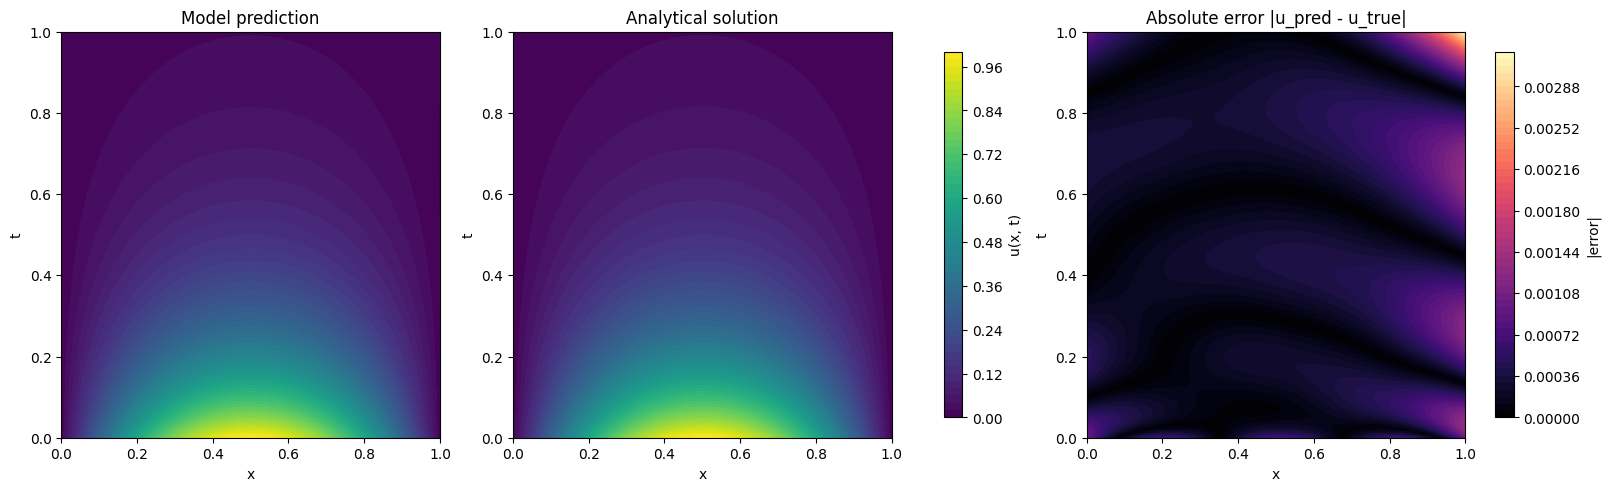

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Evaluate prediction and analytical solution on a regular grid (Problema 3)
alpha_raw = alpha.value if hasattr(alpha, "value") else alpha
if hasattr(alpha_raw, "detach"):
    alpha_val = float(alpha_raw.detach().cpu().item())
else:
    alpha_val = float(np.asarray(alpha_raw).squeeze())

n = 100
xv = np.linspace(0.0, 1.0, n)
tv = np.linspace(0.0, 1.0, n)
X, T = np.meshgrid(xv, tv)
XT = np.hstack([X.reshape(-1, 1), T.reshape(-1, 1)])

u_pred = model.predict(XT).reshape(n, n)
u_true = np.exp(-alpha_val * np.pi**2 * T) * np.sin(np.pi * X)
error_abs = np.abs(u_pred - u_true)

# Shared color scale for prediction vs analytical comparison
vmin = min(u_pred.min(), u_true.min())
vmax = max(u_pred.max(), u_true.max())

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

im0 = axes[0].contourf(X, T, u_pred, levels=60, cmap="viridis", vmin=vmin, vmax=vmax)
axes[0].set_title("Model prediction")
axes[0].set_xlabel("x")
axes[0].set_ylabel("t")

im1 = axes[1].contourf(X, T, u_true, levels=60, cmap="viridis", vmin=vmin, vmax=vmax)
axes[1].set_title("Analytical solution")
axes[1].set_xlabel("x")
axes[1].set_ylabel("t")

im2 = axes[2].contourf(X, T, error_abs, levels=60, cmap="magma")
axes[2].set_title("Absolute error |u_pred - u_true|")
axes[2].set_xlabel("x")
axes[2].set_ylabel("t")

fig.colorbar(im1, ax=axes[:2], shrink=0.9, label="u(x, t)")
fig.colorbar(im2, ax=axes[2], shrink=0.9, label="|error|")
plt.show()

---

## Problema 4: Viga estática simplemente apoyada

Considere una viga unidimensional simplemente apoyada, modelada en forma adimensional por la ecuación de Euler-Bernoulli

$$
\hat{w}_{\xi\xi\xi\xi}(\xi) = 1, \qquad \xi \in (0,1)
$$

donde $\hat{w}(\xi)$ representa la deflexión adimensional de la viga.

Las condiciones de borde para una viga simplemente apoyada son:

$$
\hat{w}(0)=0, \qquad \hat{w}(1)=0,
$$

$$
\hat{w}''(0)=0, \qquad \hat{w}''(1)=0.
$$

La solución analítica del problema es

$$
\hat{w}(\xi) = \frac{\xi\,(1 - 2\xi^2 + \xi^3)}{24}.
$$

Resolver este problema con `DeepXDE` usando el backend de PyTorch.

1. Definir la geometría unidimensional sobre el intervalo $[0,1]$.
2. Implementar la PDE usando derivadas automáticas hasta cuarto orden.
3. Imponer las condiciones de borde esenciales $\hat{w}(0)=\hat{w}(1)=0$ con `dde.icbc.DirichletBC`.
4. Imponer las condiciones de borde naturales $\hat{w}''(0)=\hat{w}''(1)=0$ con `dde.icbc.OperatorBC`.
5. Construir el objeto `dde.data.PDE`, entrenar una red `FNN` primero con Adam y luego refinar con L-BFGS.
6. Evaluar la solución aprendida en una grilla uniforme, compararla con la solución analítica y reportar el error relativo $L^2$.
7. Graficar la solución exacta, la aproximación de la PINN y el error absoluto.

In [45]:
#Resolver el problema de la viga estática 1D con DeepXDE
import torch
import deepxde as dde
from torch import nn
# Definir geometria del intervalo [0, 1]
geom = dde.geometry.Interval(0.0, 1.0)
# Definir la PDE: E u''''(x) = f(x), con E=1 y f(x)=1
def pde(x, u):
    u_x = dde.grad.jacobian(u, x, i=0, j=0)
    u_xx = dde.grad.jacobian(u_x, x, i=0, j=0)
    u_xxx = dde.grad.jacobian(u_xx, x, i=0, j=0)
    u_xxxx = dde.grad.jacobian(u_xxx, x, i=0, j=0)
    return u_xxxx - 1.0

# Condiciones de frontera: u(0)=0, u'(0)=0, u(1)=0, u'(1)=0
def boundary(x, on_boundary):
    return on_boundary
def boundary_value(x):
    return 0.0


In [43]:
# Construir BCs para la viga
bc = dde.icbc.DirichletBC(geom, boundary_value, on_boundary=boundary)
def second_derivative_zero(x, y, _):
    return dde.grad.hessian(y, x, i=0, j=0)

bc_derivative = dde.icbc.OperatorBC(geom, second_derivative_zero, on_boundary=boundary)

In [51]:
def exact_solution(x):
    return x*(1-2*x**2+x**3)/24

data = dde.data.PDE(
    geom,
    pde,
    [bc, bc_derivative],
    num_domain=3000,
    num_boundary=200,
    num_test=2000,
    solution=exact_solution,
)

net = dde.nn.FNN([1] + [50] * 5 + [1], "tanh", "Glorot normal")
model = dde.Model(data, net)
model.compile("adam", lr=0.001, metrics=["l2 relative error"])
train_loss_history = model.train(epochs=1000, display_every=100)


Compiling model...
'compile' took 0.000648 s

Training model...

Step      Train loss                        Test loss                         Test metric   
0         [1.63e+00, 3.91e-02, 1.03e-02]    [1.66e+00, 3.91e-02, 1.03e-02]    [2.10e+01]    
100       [7.59e-02, 6.89e-04, 4.25e-02]    [6.06e-02, 6.89e-04, 4.25e-02]    [2.49e+00]    
200       [4.08e-02, 1.16e-03, 1.98e-02]    [3.21e-02, 1.16e-03, 1.98e-02]    [2.72e+00]    
300       [3.73e-04, 2.46e-07, 1.53e-05]    [3.12e-04, 2.46e-07, 1.53e-05]    [4.14e-02]    
400       [2.32e-04, 8.75e-08, 1.36e-06]    [1.81e-04, 8.75e-08, 1.36e-06]    [2.24e-02]    
500       [1.34e-04, 3.33e-08, 6.43e-07]    [1.04e-04, 3.33e-08, 6.43e-07]    [1.37e-02]    
600       [7.41e-05, 2.68e-07, 7.94e-07]    [5.31e-05, 2.68e-07, 7.94e-07]    [6.59e-02]    
700       [1.79e-04, 8.17e-06, 3.99e-06]    [1.56e-04, 8.17e-06, 3.99e-06]    [3.35e-01]    
800       [2.02e-05, 5.35e-07, 1.46e-08]    [1.99e-05, 5.35e-07, 1.46e-08]    [8.01e-02]    
900  

In [52]:
#Refinement with L-BFGS
model.compile("L-BFGS")
model.train()

Compiling model...
'compile' took 0.000901 s

Training model...

Step      Train loss                        Test loss                         Test metric
1000      [5.19e-06, 1.19e-07, 2.21e-09]    [4.44e-06, 1.19e-07, 2.21e-09]    []  
1025      [1.03e-06, 2.35e-11, 5.45e-11]    [9.10e-07, 2.35e-11, 5.45e-11]    []  

Best model at step 1025:
  train loss: 1.03e-06
  test loss: 9.11e-07
  test metric: []

'train' took 10.340701 s



(<deepxde.model.LossHistory at 0x1564becbf80>,
 <deepxde.model.TrainState at 0x1564beca390>)

Error relativo L2: 2.927253e-04


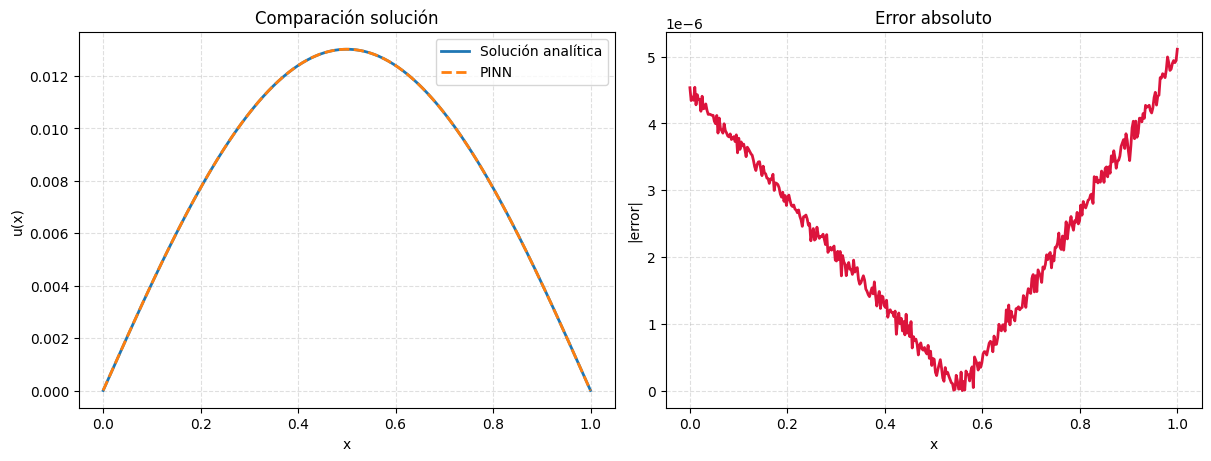

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# Grilla uniforme en [0,1]
n = 400
x = np.linspace(0.0, 1.0, n).reshape(-1, 1)

# Predicción PINN
u_pred = model.predict(x).reshape(-1, 1)

# Solución analítica (ya definida en tu notebook como exact_solution)
u_true = exact_solution(x).reshape(-1, 1)

# Error relativo L2
l2_rel = np.linalg.norm(u_pred - u_true, 2) / np.linalg.norm(u_true, 2)
print(f"Error relativo L2: {l2_rel:.6e}")

# Gráfico comparación + error absoluto
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

ax[0].plot(x, u_true, label="Solución analítica", linewidth=2)
ax[0].plot(x, u_pred, "--", label="PINN", linewidth=2)
ax[0].set_xlabel("x")
ax[0].set_ylabel("u(x)")
ax[0].set_title("Comparación solución")
ax[0].grid(True, ls="--", alpha=0.4)
ax[0].legend()

ax[1].plot(x, np.abs(u_pred - u_true), color="crimson", linewidth=2)
ax[1].set_xlabel("x")
ax[1].set_ylabel("|error|")
ax[1].set_title("Error absoluto")
ax[1].grid(True, ls="--", alpha=0.4)

plt.show()

---

## Problema 5: Viga dinámica apoyada

Considere ahora la versión dinámica de la viga apoyada, modelada en variables adimensionales por la ecuación

$$
\hat{w}_{\tau\tau}(\xi,\tau) + \hat{w}_{\xi\xi\xi\xi}(\xi,\tau) = 0,
$$

para $(\xi,\tau) \in (0,1) \times (0,1)$, donde $\hat{w}(\xi,\tau)$ representa la deflexión transversal adimensional.

Las condiciones de borde espaciales de una viga simplemente apoyada son

$$
\hat{w}(0,\tau)=0, \qquad \hat{w}(1,\tau)=0,
$$

$$
\hat{w}_{\xi\xi}(0,\tau)=0, \qquad \hat{w}_{\xi\xi}(1,\tau)=0.
$$

Además, se imponen las condiciones iniciales

$$
\hat{w}(\xi,0)=a\sin(\pi \xi), \qquad \hat{w}_{\tau}(\xi,0)=0,
$$

donde $a>0$ es una amplitud dada.

La solución exacta correspondiente al primer modo es

$$
\hat{w}(\xi,\tau)=a\sin(\pi\xi)\cos(\pi^2\tau).
$$

Resolver este problema con `DeepXDE` usando el backend de PyTorch.


1. Definir el dominio espacio-temporal usando `dde.geometry.Interval`, `dde.geometry.TimeDomain` y `dde.geometry.GeometryXTime`.
2. Implementar la PDE dinámica usando derivadas automáticas de segundo orden en tiempo y cuarto orden en espacio.
3. Imponer las condiciones de borde esenciales $\hat{w}=0$ con `dde.icbc.DirichletBC` y las condiciones naturales $\hat{w}_{\xi\xi}=0$ con `dde.icbc.OperatorBC`.
4. Imponer las condiciones iniciales de desplazamiento y velocidad usando `dde.icbc.IC` y `dde.icbc.OperatorBC`.
5. Construir un objeto `dde.data.TimePDE`, entrenar una red `FNN` con Adam, usar pesos apropiados en la loss. OPCIONAL: puede investigar como implementar un callback `dde.callbacks.PDEPointResampler` para remuestrear puntos de colocación cada 200 iteraciones.
6. Refinar la solución con el optimizador `L-BFGS`.
7. Evaluar el error relativo $L^2$ para distintos tiempos sobre una grilla espacial uniforme.
8. Graficar perfiles de la solución PINN para varios tiempos y comparar la solución exacta con la aproximación para un tiempo fijo.
9. OPCIONAL: Generar una animación o GIF que muestre la evolución temporal de la deformación de la viga y la comparación entre solución exacta y PINN.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.environ["DDE_BACKEND"] = "pytorch"

import deepxde as dde
import torch

geom = dde.geometry.Interval(0.0, 1.0)
time_domain = dde.geometry.TimeDomain(0.0, 1.0)
geomtime = dde.geometry.GeometryXTime(geom, time_domain)

def boundary(x, on_boundary):
    return on_boundary

def boundary_value(x):
    return 0.0

bc = dde.icbc.DirichletBC(geomtime, boundary_value, boundary)

#Set second derivative zero at boundaries
def second_derivative_zero(x, y, _):
    return dde.grad.hessian(y, x, i=0, j=0)

bc_derivative = dde.icbc.OperatorBC(geomtime, second_derivative_zero, on_boundary=boundary)

def pde(x, u):
    u_tt = dde.grad.hessian(u, x, i=1, j=1)   # d2u/dt2
    u_xx = dde.grad.hessian(u, x, i=0, j=0)   # d2u/dx2
    u_xxxx = dde.grad.hessian(u_xx, x, i=0, j=0)  # d4u/dx4
    return u_tt + u_xxxx

# Set initial condition \hat{w}(\xi,0)=a\sin(\pi \xi), \qquad \hat{w}_{\tau}(\xi,0)=0
def initial_condition(x):
    return np.sin(np.pi * x[:, 0:1])

ic = dde.icbc.IC(geomtime, initial_condition, lambda _, on_initial: on_initial)
def on_initial_time(x, _):
    return np.isclose(x[1], 0.0, atol=1e-6)

ic_derivative = dde.icbc.OperatorBC(
    geomtime,
    lambda x, y, _: dde.grad.jacobian(y, x, i=0, j=1),  # w_t
    on_initial_time,
)

def exact_solution(x):
    return np.sin(np.pi * x[:, 0:1]) * np.cos(np.pi**2 * x[:, 1:2])

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


<!-- TODO (Markdown): comparación entre PyTorch manual, DeepXDE y PINA -->

In [12]:
import deepxde as dde
import numpy as np

class MovingAverageAdaptiveWeights(dde.callbacks.Callback):
    """
    Callback personalizado para actualizar los pesos de la función de pérdida 
    dinámicamente sin recompilar el modelo, preservando el momentum de Adam.
    """
    def __init__(self, alpha=0.1, update_every=100):
        super().__init__()
        self.alpha = alpha  # Factor de suavizado (0 = sin cambio, 1 = salto brusco)
        self.update_every = update_every

    def on_epoch_end(self):
        # Actualizamos periódicamente para mayor estabilidad
        if self.model.train_state.step % self.update_every == 0 and self.model.train_state.step > 0:
            losses = np.array(self.model.train_state.loss_train)
            
            # 1. Prevenir división por cero en caso de convergencia perfecta
            losses = np.where(losses == 0, 1e-8, losses)
            
            # 2. Calcular los pesos objetivo basándose en la pérdida máxima
            max_loss = np.max(losses)
            target_weights = max_loss / losses
            
            # 3. Actualización in-place usando Suavizado Exponencial (EMA)
            for i in range(len(self.model.loss_weights)):
                self.model.loss_weights[i] = (
                    (1 - self.alpha) * self.model.loss_weights[i] + 
                    self.alpha * target_weights[i]
                )

# --- DEFINICIÓN DE DATOS ---
# Asumiendo que geomtime, pde, bc, ic, exact_solution ya están definidos
data = dde.data.TimePDE(
    geomtime,
    pde,
    [bc, bc_derivative, ic, ic_derivative],
    num_domain=3000,
    num_boundary=200,
    num_initial=200,
    num_test=3000,
    solution=exact_solution,
)

net = dde.nn.FNN([2] + [50] * 3 + [1], "tanh", "Glorot normal")
model = dde.Model(data, net)

# --- CONFIGURACIÓN DE CALLBACKS ---
resampler = dde.callbacks.PDEPointResampler(period=200)
# alpha=0.1 proporciona un ajuste suave. update_every sincroniza con tu resampler.
adaptive_weights = MovingAverageAdaptiveWeights(alpha=0.1, update_every=200)

initial_weights = [1.0, 10.0, 10.0, 50.0, 10.0]

# --- ENTRENAMIENTO ADAM (Sin bucles de ráfagas) ---
model.compile(
    "adam",
    lr=0.005,
    loss_weights=initial_weights,
    metrics=["l2 relative error"],
)

# El entrenamiento se ejecuta de corrido. El callback modifica los pesos por detrás.
losshistory, train_state = model.train(
    epochs=10000,
    display_every=100,
    callbacks=[resampler]#, adaptive_weights]
)



Compiling model...
'compile' took 0.000103 s

Training model...

0         [9.26e-02, 3.67e-01, 9.82e-02, 2.87e+01, 8.30e-01]    [9.64e-02, 3.67e-01, 9.82e-02, 2.87e+01, 8.30e-01]    [1.04e+00]    
100       [3.15e-01, 1.23e+00, 1.52e-01, 4.41e+00, 8.54e-02]    [2.49e-01, 1.23e+00, 1.52e-01, 4.41e+00, 8.54e-02]    [1.12e+00]    
200       [2.22e-01, 9.02e-01, 5.00e-01, 3.58e+00, 1.18e-01]    [1.45e-01, 9.02e-01, 5.00e-01, 3.58e+00, 1.18e-01]    [1.05e+00]    
300       [2.84e-01, 7.84e-01, 4.43e-01, 2.97e+00, 4.80e-02]    [1.79e-01, 7.84e-01, 4.43e-01, 2.97e+00, 4.80e-02]    [1.03e+00]    
400       [2.42e-01, 5.60e-01, 5.14e-01, 2.10e+00, 1.97e-02]    [1.63e-01, 5.60e-01, 5.14e-01, 2.10e+00, 1.97e-02]    [9.70e-01]    
500       [3.12e+00, 4.64e-01, 6.76e-01, 1.73e+00, 1.22e-02]    [2.15e+00, 4.64e-01, 6.76e-01, 1.73e+00, 1.22e-02]    [9.41e-01]    
600       [4.21e-01, 3.78e-01, 5.50e-01, 1.38e+00, 2.01e-02]    [3.30e-01, 3.78e-01, 5.50e-01, 1.38e+00, 2.01e-02]    [9.21e-01]    
700 

KeyboardInterrupt: 

In [13]:
adaptive_weights = MovingAverageAdaptiveWeights(alpha=0.01, update_every=200)

# El entrenamiento se ejecuta de corrido. El callback modifica los pesos por detrás.
losshistory, train_state = model.train(
    epochs=10000,
    display_every=100,
    callbacks=[resampler, adaptive_weights]
)

Training model...

4712      [4.56e-02, 1.62e-01, 3.73e-02, 5.91e-02, 2.43e-02]    [3.88e-02, 1.62e-01, 3.73e-02, 5.91e-02, 2.43e-02]    [7.25e-01]    
4800      [6.13e-02, 1.60e-01, 3.58e-02, 5.06e-02, 2.38e-02]    [5.15e-02, 1.60e-01, 3.58e-02, 5.06e-02, 2.38e-02]    [7.18e-01]    
4900      [4.61e-02, 1.57e-01, 3.37e-02, 4.96e-02, 2.38e-02]    [3.96e-02, 1.57e-01, 3.37e-02, 4.96e-02, 2.38e-02]    [7.17e-01]    
5000      [4.38e-02, 1.56e-01, 3.21e-02, 4.56e-02, 2.35e-02]    [3.76e-02, 1.56e-01, 3.21e-02, 4.56e-02, 2.35e-02]    [7.15e-01]    
5100      [3.08e-02, 1.65e-01, 3.40e-02, 1.05e-01, 2.08e-02]    [2.57e-02, 1.65e-01, 3.40e-02, 1.05e-01, 2.08e-02]    [7.44e-01]    
5200      [4.93e-02, 1.62e-01, 2.39e-02, 1.03e-01, 2.22e-02]    [3.91e-02, 1.62e-01, 2.39e-02, 1.03e-01, 2.22e-02]    [7.31e-01]    
5300      [1.42e-01, 1.56e-01, 3.08e-02, 1.28e-01, 2.35e-02]    [1.28e-01, 1.56e-01, 3.08e-02, 1.28e-01, 2.35e-02]    [7.25e-01]    
5400      [9.69e-02, 1.48e-01, 2.62e-02, 5.38e-02,

KeyboardInterrupt: 

In [18]:
# --- REFINAMIENTO L-BFGS ---
# L-BFGS heredará automáticamente el último estado de model.loss_weights 
# calculado por el callback durante la fase de Adam.
model.compile("L-BFGS", loss_weights=model.loss_weights, metrics=["l2 relative error"])
model.train(display_every=100, callbacks=[adaptive_weights], epochs=5000)

Compiling model...
'compile' took 0.001398 s

Training model...

6928      [1.24e-01, 1.43e-01, 1.80e-02, 1.65e-01, 4.21e-02]    [1.21e-01, 1.43e-01, 1.80e-02, 1.65e-01, 4.21e-02]    [7.13e-01]    
7928      [8.74e-03, 9.52e-02, 2.44e-03, 9.19e-04, 7.60e-05]    [8.04e-03, 9.52e-02, 2.44e-03, 9.19e-04, 7.60e-05]    [5.17e-01]    
8928      [1.24e-02, 2.43e-02, 1.62e-03, 3.48e-04, 3.80e-05]    [1.20e-02, 2.43e-02, 1.62e-03, 3.48e-04, 3.80e-05]    [2.63e-01]    
9928      [4.13e-03, 3.63e-03, 8.02e-04, 2.08e-05, 3.35e-05]    [4.41e-03, 3.63e-03, 8.02e-04, 2.08e-05, 3.35e-05]    [8.63e-02]    
10928     [2.15e-03, 1.68e-03, 1.79e-04, 7.02e-06, 2.02e-05]    [2.58e-03, 1.68e-03, 1.79e-04, 7.02e-06, 2.02e-05]    [4.22e-02]    
11928     [1.59e-03, 9.32e-04, 1.86e-04, 1.21e-05, 7.17e-05]    [2.04e-03, 9.32e-04, 1.86e-04, 1.21e-05, 7.17e-05]    [2.01e-02]    
12928     [1.04e-03, 7.28e-04, 1.98e-04, 2.06e-07, 2.54e-05]    [1.16e-03, 7.28e-04, 1.98e-04, 2.06e-07, 2.54e-05]    [1.78e-02]    


KeyboardInterrupt: 

In [42]:

adaptive_weights = MovingAverageAdaptiveWeights(alpha=0.5, update_every=50)
resampler = dde.callbacks.PDEPointResampler(period=10)

model.compile("L-BFGS", loss_weights=model.loss_weights, metrics=["l2 relative error"])
model.train(display_every=100, callbacks=[resampler,adaptive_weights])

Compiling model...
'compile' took 0.000811 s

Training model...

Step      Train loss                                            Test loss                                             Test metric   
27886     [6.68e-04, 3.83e-04, 8.20e-05, 5.75e-07, 9.29e-06]    [7.64e-04, 3.83e-04, 8.20e-05, 5.75e-07, 9.29e-06]    [1.03e-02]    

Best model at step 27886:
  train loss: 1.14e-03
  test loss: 1.24e-03
  test metric: [1.03e-02]

'train' took 2.056904 s



(<deepxde.model.LossHistory at 0x13f6f579fd0>,
 <deepxde.model.TrainState at 0x13f6f57b380>)

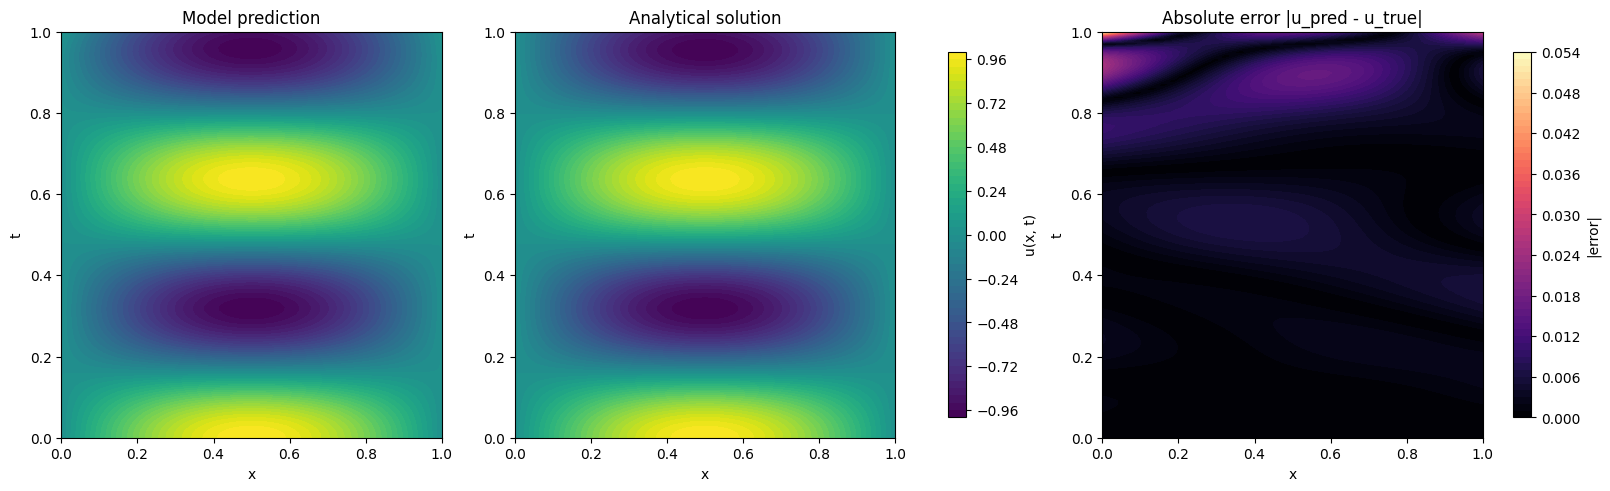

In [40]:
import numpy as np
import matplotlib.pyplot as plt

n = 100
xv = np.linspace(0.0, 1.0, n)
tv = np.linspace(0.0, 1.0, n)
X, T = np.meshgrid(xv, tv)
XT = np.hstack([X.reshape(-1, 1), T.reshape(-1, 1)])

u_pred = model.predict(XT).reshape(n, n)
u_true = exact_solution(XT).reshape(n, n)
error_abs = np.abs(u_pred - u_true)

# Shared color scale for prediction vs analytical comparison
vmin = min(u_pred.min(), u_true.min())
vmax = max(u_pred.max(), u_true.max())

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

im0 = axes[0].contourf(X, T, u_pred, levels=60, cmap="viridis", vmin=vmin, vmax=vmax)
axes[0].set_title("Model prediction")
axes[0].set_xlabel("x")
axes[0].set_ylabel("t")

im1 = axes[1].contourf(X, T, u_true, levels=60, cmap="viridis", vmin=vmin, vmax=vmax)
axes[1].set_title("Analytical solution")
axes[1].set_xlabel("x")
axes[1].set_ylabel("t")

im2 = axes[2].contourf(X, T, error_abs, levels=60, cmap="magma")
axes[2].set_title("Absolute error |u_pred - u_true|")
axes[2].set_xlabel("x")
axes[2].set_ylabel("t")

fig.colorbar(im1, ax=axes[:2], shrink=0.9, label="u(x, t)")
fig.colorbar(im2, ax=axes[2], shrink=0.9, label="|error|")
plt.show()

GIF guardado en: viga_dinamica_exacta_vs_pinn.gif


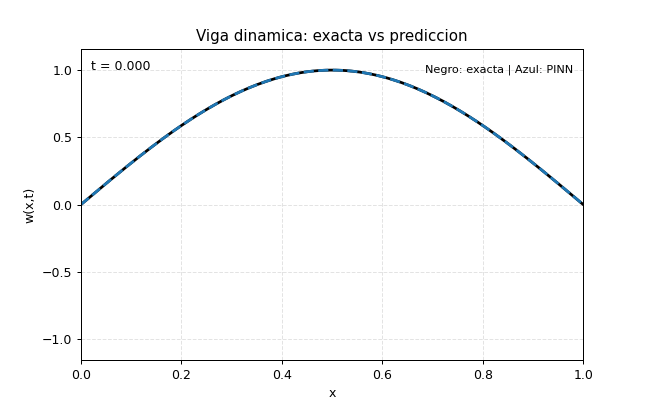

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

# GIF: deformacion de la viga en el tiempo (exacta vs prediccion) en un mismo grafico
# Version optimizada para exportar mas rapido
x = np.linspace(0.0, 1.0, 180)
t_vals = np.linspace(0.0, 1.0, 48)

# Precalculo de curvas por frame
u_pred_frames = np.empty((len(t_vals), len(x)))
u_true_frames = np.empty((len(t_vals), len(x)))
for k, t in enumerate(t_vals):
    xt = np.column_stack([x, np.full_like(x, t)])
    u_pred_frames[k] = model.predict(xt).reshape(-1)
    u_true_frames[k] = exact_solution(xt).reshape(-1)

# Limites verticales compartidos
ymin = float(min(u_pred_frames.min(), u_true_frames.min()))
ymax = float(max(u_pred_frames.max(), u_true_frames.max()))
pad = 0.08 * (ymax - ymin + 1e-12)

fig, ax = plt.subplots(figsize=(7.2, 4.5), dpi=90)
line_true, = ax.plot([], [], lw=2.2, color="black")
line_pred, = ax.plot([], [], lw=2.2, ls="--", color="tab:blue")
text_t = ax.text(0.02, 0.93, "", transform=ax.transAxes)

# Etiquetas estaticas para evitar recalculo costoso de leyenda por frame
ax.text(0.98, 0.95, "Negro: exacta | Azul: PINN", transform=ax.transAxes,
        ha="right", va="top", fontsize=9)

ax.set_xlim(0.0, 1.0)
ax.set_ylim(ymin - pad, ymax + pad)
ax.set_xlabel("x")
ax.set_ylabel("w(x,t)")
ax.set_title("Viga dinamica: exacta vs prediccion")
ax.grid(True, ls="--", alpha=0.35)


def init():
    line_true.set_data([], [])
    line_pred.set_data([], [])
    text_t.set_text("")
    return line_true, line_pred, text_t


def update(frame):
    line_true.set_data(x, u_true_frames[frame])
    line_pred.set_data(x, u_pred_frames[frame])
    text_t.set_text(f"t = {t_vals[frame]:.3f}")
    return line_true, line_pred, text_t


anim = FuncAnimation(
    fig,
    update,
    frames=len(t_vals),
    init_func=init,
    interval=70,
    blit=True,
)

gif_path = "viga_dinamica_exacta_vs_pinn.gif"
anim.save(gif_path, writer=PillowWriter(fps=14))
plt.close(fig)

print(f"GIF guardado en: {gif_path}")
display(Image(filename=gif_path))

In [36]:
import os
import torch
import json
from datetime import datetime

# Crear directorio para guardar modelos
save_dir = "modelos_entrenados"
os.makedirs(save_dir, exist_ok=True)

# Nombre base con timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_name = f"viga_dinamica_{timestamp}"

# 1. Guardar pesos del modelo (DeepXDE + PyTorch)
model_weights_path = os.path.join(save_dir, f"{model_name}_weights.pth")
torch.save(net.state_dict(), model_weights_path)
print(f"✓ Pesos del modelo guardados en: {model_weights_path}")

# 2. Guardar metadatos e hiperparámetros
# Obtener pesos finales si están disponibles, sino usar lista vacía
try:
    pesos_finales = current_weights if 'current_weights' in locals() else [1.0, 10.0, 10.0, 50.0, 10.0]
except:
    pesos_finales = [1.0, 10.0, 10.0, 50.0, 10.0]

metadata = {
    "modelo": "PINN - Viga dinámica apoyada",
    "timestamp": timestamp,
    "arquitectura": {
        "input_dim": 2,
        "capas_ocultas": [50, 50, 50],
        "output_dim": 1,
        "activacion": "tanh",
        "inicializacion": "Glorot normal"
    },
    "hiperparametros_entrenamiento": {
        "lr_adam": 0.001,
        "epochs_adam": 1000,
        "optimizer_refinamiento": "L-BFGS",
        "num_domain": 3000,
        "num_boundary": 200,
        "num_initial": 200,
        "num_test": 3000
    },
    "pesos_loss_finales": pesos_finales,
    "dominio": {
        "x": [0.0, 1.0],
        "t": [0.0, 1.0]
    },
    "ecuacion": "w_tt + w_xxxx = 0 (viga dinámica)",
    "condiciones_iniciales": {
        "desplazamiento": "w(x,0) = sin(pi*x)",
        "velocidad": "w_t(x,0) = 0"
    },
    "condiciones_borde": {
        "dirichlet": "w(0,t) = w(1,t) = 0",
        "natural": "w_xx(0,t) = w_xx(1,t) = 0"
    },
    "solucion_exacta": "w(x,t) = sin(pi*x)*cos(pi^2*t)"
}

metadata_path = os.path.join(save_dir, f"{model_name}_metadata.json")
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Metadatos guardados en: {metadata_path}")

# 3. Guardar configuración completa del modelo (incluye arquitectura + pesos)
model_config_path = os.path.join(save_dir, f"{model_name}_config.pth")
model_config = {
    "net_state_dict": net.state_dict(),
    "metadata": metadata
}
torch.save(model_config, model_config_path)
print(f"✓ Configuración completa guardada en: {model_config_path}")

print(f"\n{'='*60}")
print(f"Resumen de guardado:")
print(f"{'='*60}")
print(f"Directorio: {save_dir}")
print(f"Prefijo de archivos: {model_name}")
print(f"Archivos generados:")
print(f"  - {model_name}_weights.pth       (solo pesos)")
print(f"  - {model_name}_metadata.json    (hiperparámetros)")
print(f"  - {model_name}_config.pth       (completo)")
print(f"{'='*60}")

✓ Pesos del modelo guardados en: modelos_entrenados\viga_dinamica_20260428_120108_weights.pth
✓ Metadatos guardados en: modelos_entrenados\viga_dinamica_20260428_120108_metadata.json
✓ Configuración completa guardada en: modelos_entrenados\viga_dinamica_20260428_120108_config.pth

Resumen de guardado:
Directorio: modelos_entrenados
Prefijo de archivos: viga_dinamica_20260428_120108
Archivos generados:
  - viga_dinamica_20260428_120108_weights.pth       (solo pesos)
  - viga_dinamica_20260428_120108_metadata.json    (hiperparámetros)
  - viga_dinamica_20260428_120108_config.pth       (completo)
